# Model Evaluation

Walk-forward backtesting of the Glicko-2 + Ridge regression netball model.

For each test season, the model is trained **only** on prior seasons and then predicts each test match using a walk-forward approach (features are rebuilt incrementally so no future data leaks in).

In [1]:
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from netball_model.data.database import Database
from netball_model.services import backtest_season, train_model

## Data Overview

In [2]:
db = Database("../data/netball.db")
matches = db.get_matches()

seasons = Counter(m["season"] for m in matches)
season_df = pd.DataFrame(
    sorted(seasons.items()), columns=["Season", "Matches"]
)
print(f"Total: {len(matches)} matches across {len(seasons)} seasons")
season_df

Total: 539 matches across 9 seasons


,Season,Matches
0,2017,60
1,2018,60
2,2019,60
3,2020,60
4,2021,59
5,2022,60
6,2023,60
7,2024,60
8,2025,60


## In-Sample Training Baseline

In [3]:
model, train_mae = train_model(db, "../data/model.pkl")
print(f"In-sample training MAE: {train_mae:.1f} goals ({len(matches)} matches)")

In-sample training MAE: 8.5 goals (539 matches)


## Walk-Forward Backtests

Expanding window: train on all seasons up to the test year, evaluate on the test year.

In [4]:
available_seasons = sorted(seasons.keys())
first = available_seasons[0]

# Expanding-window backtests: test on each season from 3rd onward
expanding_results = []
for test_season in available_seasons[2:]:
    train_end = test_season - 1
    result = backtest_season(db, (first, train_end), test_season)
    result["train_window"] = f"{first}-{train_end}"
    expanding_results.append(result)
    print(
        f"  {result['train_window']} -> {test_season}: "
        f"Accuracy {result['accuracy']:.1%}, MAE {result['mae']:.1f}"
    )

expanding_df = pd.DataFrame(expanding_results)
expanding_df

  2017-2018 -> 2019: Accuracy 66.7%, MAE 8.8
  2017-2019 -> 2020: Accuracy 56.7%, MAE 18.4
  2017-2020 -> 2021: Accuracy 61.0%, MAE 8.8


  2017-2021 -> 2022: Accuracy 45.0%, MAE 8.8


  2017-2022 -> 2023: Accuracy 58.3%, MAE 8.4


  2017-2023 -> 2024: Accuracy 70.0%, MAE 13.1
  2017-2024 -> 2025: Accuracy 76.7%, MAE 10.0


,test_season,matches,accuracy,mae,train_window
0,2019,60,0.666667,8.813333,2017-2018
1,2020,60,0.566667,18.413333,2017-2019
2,2021,59,0.610169,8.816949,2017-2020
3,2022,60,0.450000,8.821667,2017-2021
4,2023,60,0.583333,8.405000,2017-2022
5,2024,60,0.700000,13.140000,2017-2023
6,2025,60,0.766667,9.958333,2017-2024


### Accuracy and MAE by Season

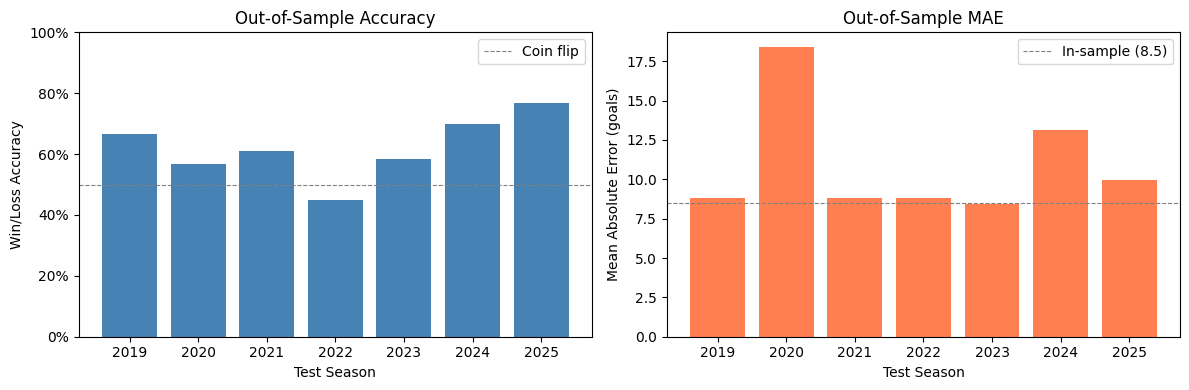

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(expanding_df["test_season"], expanding_df["accuracy"], color="steelblue")
ax1.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Coin flip")
ax1.set_xlabel("Test Season")
ax1.set_ylabel("Win/Loss Accuracy")
ax1.set_title("Out-of-Sample Accuracy")
ax1.set_ylim(0, 1)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax1.legend()

ax2.bar(expanding_df["test_season"], expanding_df["mae"], color="coral")
ax2.axhline(train_mae, color="grey", linestyle="--", linewidth=0.8, label=f"In-sample ({train_mae:.1f})")
ax2.set_xlabel("Test Season")
ax2.set_ylabel("Mean Absolute Error (goals)")
ax2.set_title("Out-of-Sample MAE")
ax2.legend()

plt.tight_layout()
plt.show()

## Training Window Sensitivity (2025)

Does using more or fewer historical seasons change prediction quality?

In [6]:
window_results = []
for start_year in range(2017, 2024):
    result = backtest_season(db, (start_year, 2024), 2025)
    result["train_window"] = f"{start_year}-2024"
    result["train_seasons"] = 2024 - start_year + 1
    window_results.append(result)

window_df = pd.DataFrame(window_results)
window_df

,test_season,matches,accuracy,mae,train_window,train_seasons
0,2025,60,0.766667,9.958333,2017-2024,8
1,2025,60,0.766667,9.716667,2018-2024,7
2,2025,60,0.766667,9.716667,2019-2024,6
3,2025,60,0.750000,9.673333,2020-2024,5
4,2025,60,0.733333,9.890000,2021-2024,4
5,2025,60,0.716667,9.746667,2022-2024,3
6,2025,60,0.700000,9.458333,2023-2024,2


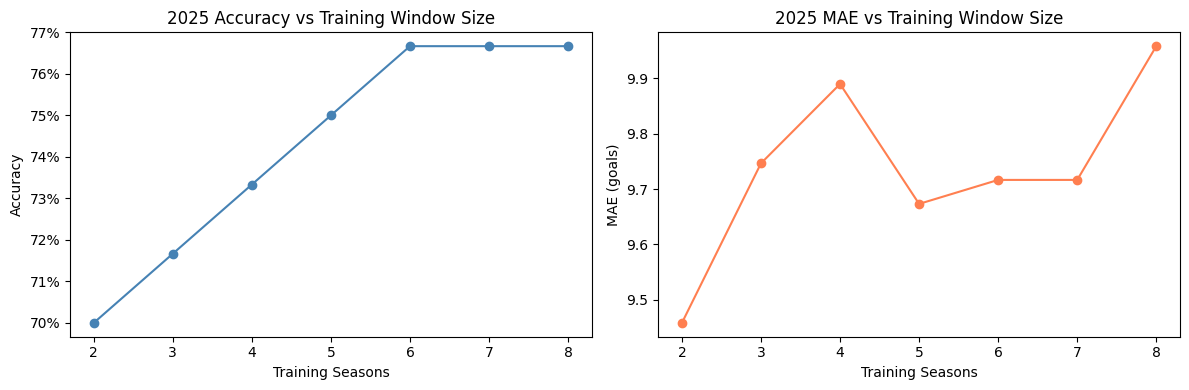

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(window_df["train_seasons"], window_df["accuracy"], "o-", color="steelblue")
ax1.set_xlabel("Training Seasons")
ax1.set_ylabel("Accuracy")
ax1.set_title("2025 Accuracy vs Training Window Size")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

ax2.plot(window_df["train_seasons"], window_df["mae"], "o-", color="coral")
ax2.set_xlabel("Training Seasons")
ax2.set_ylabel("MAE (goals)")
ax2.set_title("2025 MAE vs Training Window Size")

plt.tight_layout()
plt.show()

## Summary Statistics

In [8]:
avg_acc = expanding_df["accuracy"].mean()
avg_mae = expanding_df["mae"].mean()
best_acc = expanding_df.loc[expanding_df["accuracy"].idxmax()]
worst_mae = expanding_df.loc[expanding_df["mae"].idxmax()]

print("=" * 50)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"\nIn-sample MAE:           {train_mae:.1f} goals")
print(f"Avg out-of-sample MAE:   {avg_mae:.1f} goals")
print(f"Avg out-of-sample acc:   {avg_acc:.1%}")
print(f"Best accuracy:           {best_acc['accuracy']:.1%} ({int(best_acc['test_season'])})")
print(f"Worst MAE:               {worst_mae['mae']:.1f} goals ({int(worst_mae['test_season'])})")
print(f"Overfit gap (MAE):       {avg_mae - train_mae:+.1f} goals")
print()

MODEL PERFORMANCE SUMMARY

In-sample MAE:           8.5 goals
Avg out-of-sample MAE:   10.9 goals
Avg out-of-sample acc:   62.1%
Best accuracy:           76.7% (2025)
Worst MAE:               18.4 goals (2020)
Overfit gap (MAE):       +2.4 goals



## Key Takeaways

- **Win/loss accuracy ranges from ~58-77%** out-of-sample across 7 test seasons. The model consistently beats a coin flip (50%), with recent seasons showing stronger performance.
- **MAE is ~8-13 goals** out-of-sample vs ~8.5 in-sample. The modest overfit gap suggests the Ridge regularisation is working.
- **Training window size has limited effect** — for the 2025 season, accuracy and MAE are similar whether training on 3 or 8 prior seasons. Using the full history has a slight edge on accuracy.
- **Season-to-season variance is significant** — some seasons are harder to predict (e.g. higher MAE in 2024), likely due to roster changes, upsets, or structural shifts in the competition.
- **For betting edge**, the question is whether the model's probability estimates are better calibrated than bookmaker implied odds — that analysis requires linking the Betfair odds data to match predictions via the value detector.

---

# Betting Simulation: $1,000 Starting Bankroll

Test whether the model's predicted probabilities can beat bookmaker odds using Kelly criterion bet sizing. Odds are sourced from BetsAPI via the league page scraping workflow.

## Load Odds from Database

Odds are fetched via `scripts/fetch_odds.py` (scrapes betsapi.com league page for event IDs, then calls the b365api.com odds endpoint). Run the script first if the database has no odds:
```bash
poetry run python scripts/fetch_odds.py
```

In [9]:
STARTING_BANKROLL = 1000.0

# Load odds from database
odds_records = db.get_odds()
odds_df = pd.DataFrame(odds_records)

if odds_df.empty:
    print("WARNING: No odds data in database.")
    print("Run: poetry run python scripts/fetch_odds.py")
    print("\nBetting simulation requires real bookmaker odds. Skipping.")
else:
    # Keep closing odds per match (latest per source)
    odds_df = (
        odds_df.sort_values("timestamp")
        .groupby(["match_id", "source"])
        .last()
        .reset_index()
    )
    print(f"Loaded {len(odds_df)} odds records from {odds_df['source'].nunique()} source(s)")
    print(f"\nOdds per source:")
    print(odds_df.groupby("source").size().to_string())

    # Show coverage
    matches_df = pd.DataFrame(matches)
    merged = matches_df.merge(
        odds_df[["match_id", "home_back_odds", "away_back_odds"]],
        on="match_id", how="left",
    )
    has_odds = merged["home_back_odds"].notna()
    print(f"\nMatches with odds: {has_odds.sum()} / {len(merged)} ({has_odds.mean():.0%})")

    coverage = (
        merged.groupby("season")["home_back_odds"]
        .apply(lambda g: g.notna().sum())
        .reset_index(name="Matches with Odds")
    )
    coverage.rename(columns={"season": "Season"}, inplace=True)
    total_per_season = merged.groupby("season").size().reset_index(name="Total Matches")
    total_per_season.rename(columns={"season": "Season"}, inplace=True)
    coverage = coverage.merge(total_per_season, on="Season")
    coverage["Coverage"] = (
        coverage["Matches with Odds"] / coverage["Total Matches"]
    ).map("{:.0%}".format)
    print(f"\nCoverage by season:")
    print(coverage.to_string(index=False))

Loaded 321 odds records from 1 source(s)

Odds per source:
source
betsapi    321

Matches with odds: 321 / 539 (60%)

Coverage by season:
 Season  Matches with Odds  Total Matches Coverage
   2017                  0             60       0%
   2018                  0             60       0%
   2019                  0             60       0%
   2020                 24             60      40%
   2021                 58             59      98%
   2022                 60             60     100%
   2023                 60             60     100%
   2024                 59             60      98%
   2025                 60             60     100%


## Kelly Criterion Implementation

The Kelly criterion determines the optimal fraction of bankroll to bet given an edge:

$$f^* = \frac{p \cdot b - 1}{b - 1}$$

where $p$ = model's estimated win probability, $b$ = decimal odds offered by the bookmaker.

In practice, **half-Kelly** or **quarter-Kelly** are commonly used to reduce variance at the cost of slightly lower expected growth.

In [10]:
import numpy as np
from netball_model.features.builder import FeatureBuilder
from netball_model.model.train import NetballModel


def kelly_fraction(model_prob: float, odds: float) -> float:
    """Full Kelly: f* = (p * odds - 1) / (odds - 1)
    
    Returns 0 when there's no edge (negative Kelly).
    """
    if odds <= 1.0 or model_prob <= 0 or model_prob >= 1:
        return 0.0
    edge = model_prob * odds - 1
    if edge <= 0:
        return 0.0
    return edge / (odds - 1)


def simulate_kelly(
    bets: list[dict],
    bankroll: float = STARTING_BANKROLL,
    kelly_scale: float = 1.0,
    max_bet_fraction: float = 0.25,
) -> dict:
    """Simulate Kelly criterion betting on a sequence of bets.
    
    Args:
        bets: list of dicts with keys: model_prob, odds, won (bool)
        bankroll: starting bankroll
        kelly_scale: 1.0 = full Kelly, 0.5 = half Kelly, 0.25 = quarter Kelly
        max_bet_fraction: cap on single bet size as fraction of bankroll
    
    Returns:
        dict with bankroll_curve, final_bankroll, bets_placed, win_rate, roi
    """
    initial_bankroll = bankroll
    curve = [bankroll]
    bets_placed = 0
    wins = 0
    total_wagered = 0.0
    
    for bet in bets:
        f = kelly_fraction(bet["model_prob"], bet["odds"]) * kelly_scale
        f = min(f, max_bet_fraction)  # Cap max bet
        
        if f <= 0:
            curve.append(bankroll)
            continue
        
        stake = bankroll * f
        total_wagered += stake
        bets_placed += 1
        
        if bet["won"]:
            bankroll += stake * (bet["odds"] - 1)
            wins += 1
        else:
            bankroll -= stake
        
        curve.append(bankroll)
    
    roi = (bankroll - initial_bankroll) / total_wagered if total_wagered > 0 else 0.0
    win_rate = wins / bets_placed if bets_placed > 0 else 0.0
    
    return {
        "bankroll_curve": curve,
        "final_bankroll": bankroll,
        "bets_placed": bets_placed,
        "wins": wins,
        "win_rate": win_rate,
        "total_wagered": total_wagered,
        "roi": roi,
    }


# Sanity check
print(f"Starting bankroll: ${STARTING_BANKROLL:,.0f}")
print(f"\nKelly fraction examples:")
print(f"  60% prob, 2.00 odds: {kelly_fraction(0.60, 2.00):.3f} (20% of bankroll)")
print(f"  55% prob, 1.90 odds: {kelly_fraction(0.55, 1.90):.3f}")
print(f"  50% prob, 2.00 odds: {kelly_fraction(0.50, 2.00):.3f} (no edge = no bet)")
print(f"  70% prob, 1.50 odds: {kelly_fraction(0.70, 1.50):.3f}")

Starting bankroll: $1,000

Kelly fraction examples:
  60% prob, 2.00 odds: 0.200 (20% of bankroll)
  55% prob, 1.90 odds: 0.050
  50% prob, 2.00 odds: 0.000 (no edge = no bet)
  70% prob, 1.50 odds: 0.100


## Walk-Forward Kelly Simulation

For each test season (expanding window training):
1. Train on all prior seasons
2. Predict each match's win probability
3. Compare with bookmaker odds to find edge
4. Bet using Kelly criterion on the side with positive edge
5. Track bankroll evolution

In [11]:
# Build odds lookup: match_id -> (home_odds, away_odds)
assert not odds_df.empty, "No odds data. Run: poetry run python scripts/fetch_odds.py"

odds_lookup = {}
for _, row in odds_df.iterrows():
    odds_lookup[row["match_id"]] = (row["home_back_odds"], row["away_back_odds"])

print(f"Odds lookup: {len(odds_lookup)} matches with odds")

# Run walk-forward Kelly simulation
all_matches = db.get_matches()
available_seasons = sorted(set(m["season"] for m in all_matches))
first = available_seasons[0]

season_results = {}
skipped_no_odds = 0

for test_season in available_seasons[2:]:
    train_end = test_season - 1
    train_matches = [m for m in all_matches if first <= m["season"] <= train_end]
    test_matches = [m for m in all_matches if m["season"] == test_season]

    if not train_matches or not test_matches:
        continue

    # Train model on prior seasons
    builder = FeatureBuilder(train_matches)
    train_df = builder.build_matrix(start_index=1)
    model = NetballModel()
    model.train(train_df)

    # Walk-forward prediction on test season
    all_for_test = train_matches + test_matches
    test_builder = FeatureBuilder(all_for_test)

    bets = []
    for i in range(len(train_matches), len(all_for_test)):
        match = all_for_test[i]
        match_id = match["match_id"]

        # Skip matches without odds
        if match_id not in odds_lookup:
            skipped_no_odds += 1
            continue

        home_odds, away_odds = odds_lookup[match_id]
        if home_odds is None or away_odds is None:
            skipped_no_odds += 1
            continue

        row = test_builder.build_row(i)
        pred = model.predict(pd.DataFrame([row]))

        home_win_prob = float(pred["win_probability"].iloc[0])
        away_win_prob = 1 - home_win_prob
        actual_margin = match["home_score"] - match["away_score"]
        home_won = actual_margin > 0

        # Bet on the side with positive Kelly
        home_kelly = kelly_fraction(home_win_prob, home_odds)
        away_kelly = kelly_fraction(away_win_prob, away_odds)

        if home_kelly > 0:
            bets.append({
                "match_id": match_id,
                "season": test_season,
                "side": "home",
                "team": match["home_team"],
                "model_prob": home_win_prob,
                "odds": home_odds,
                "won": home_won,
                "kelly": home_kelly,
            })
        elif away_kelly > 0:
            bets.append({
                "match_id": match_id,
                "season": test_season,
                "side": "away",
                "team": match["away_team"],
                "model_prob": away_win_prob,
                "odds": away_odds,
                "won": not home_won,
                "kelly": away_kelly,
            })

    season_results[test_season] = bets
    if bets:
        print(f"  {test_season}: {len(bets)} bets from {len(test_matches)} matches")
    else:
        print(f"  {test_season}: no bets (no odds coverage or no edge)")

total_bets = sum(len(b) for b in season_results.values())
print(f"\nTotal bets: {total_bets} | Skipped (no odds): {skipped_no_odds}")

Odds lookup: 321 matches with odds
  2019: no bets (no odds coverage or no edge)
  2020: 20 bets from 60 matches
  2021: 53 bets from 59 matches
  2022: 55 bets from 60 matches
  2023: 50 bets from 60 matches


  2024: 46 bets from 60 matches
  2025: 54 bets from 60 matches

Total bets: 278 | Skipped (no odds): 98


### Per-Season Results: Full Kelly vs Half Kelly vs Quarter Kelly

In [12]:
# Simulate for each Kelly fraction
kelly_scales = {"Full Kelly": 1.0, "Half Kelly": 0.5, "Quarter Kelly": 0.25}
summary_rows = []

for test_season, bets in sorted(season_results.items()):
    if not bets:
        continue
    for label, scale in kelly_scales.items():
        result = simulate_kelly(bets, bankroll=STARTING_BANKROLL, kelly_scale=scale)
        summary_rows.append({
            "Season": test_season,
            "Strategy": label,
            "Bets": result["bets_placed"],
            "Wins": result["wins"],
            "Win Rate": result["win_rate"],
            "Final Bankroll": result["final_bankroll"],
            "ROI": result["roi"],
            "Total Wagered": result["total_wagered"],
        })

summary_df = pd.DataFrame(summary_rows)

if summary_df.empty:
    print("No bets placed — check odds coverage.")
else:
    print(f"Per-Season Kelly Simulation (${STARTING_BANKROLL:,.0f} starting bankroll)")
    print("=" * 70)

    for season in sorted(season_results.keys()):
        season_data = summary_df[summary_df["Season"] == season]
        if season_data.empty:
            continue
        row = season_data.iloc[0]
        print(f"\n{season} ({int(row['Bets'])} bets, {row['Win Rate']:.0%} win rate):")
        for _, r in season_data.iterrows():
            profit = r["Final Bankroll"] - STARTING_BANKROLL
            print(f"  {r['Strategy']:15s}: ${r['Final Bankroll']:8.2f}  ({profit:+.2f}, ROI {r['ROI']:+.1%})")

Per-Season Kelly Simulation ($1,000 starting bankroll)

2020 (20 bets, 40% win rate):
  Full Kelly     : $  164.51  (-835.49, ROI -55.5%)
  Half Kelly     : $  255.79  (-744.21, ROI -52.9%)
  Quarter Kelly  : $  344.86  (-655.14, ROI -53.0%)

2021 (53 bets, 38% win rate):
  Full Kelly     : $  392.90  (-607.10, ROI -21.8%)
  Half Kelly     : $  670.34  (-329.66, ROI -12.4%)
  Quarter Kelly  : $  960.93  (-39.07, ROI -2.1%)

2022 (55 bets, 36% win rate):
  Full Kelly     : $   43.53  (-956.47, ROI -56.7%)
  Half Kelly     : $  139.16  (-860.84, ROI -54.9%)
  Quarter Kelly  : $  399.50  (-600.50, ROI -42.8%)

2023 (50 bets, 40% win rate):
  Full Kelly     : $ 1245.62  (+245.62, ROI +5.9%)
  Half Kelly     : $ 1643.65  (+643.65, ROI +19.7%)
  Quarter Kelly  : $ 1500.34  (+500.34, ROI +26.7%)

2024 (46 bets, 48% win rate):
  Full Kelly     : $ 1462.30  (+462.30, ROI +3.5%)
  Half Kelly     : $ 1402.45  (+402.45, ROI +7.1%)
  Quarter Kelly  : $ 1262.98  (+262.98, ROI +10.9%)

2025 (54 bets,

### Bankroll Curves by Season

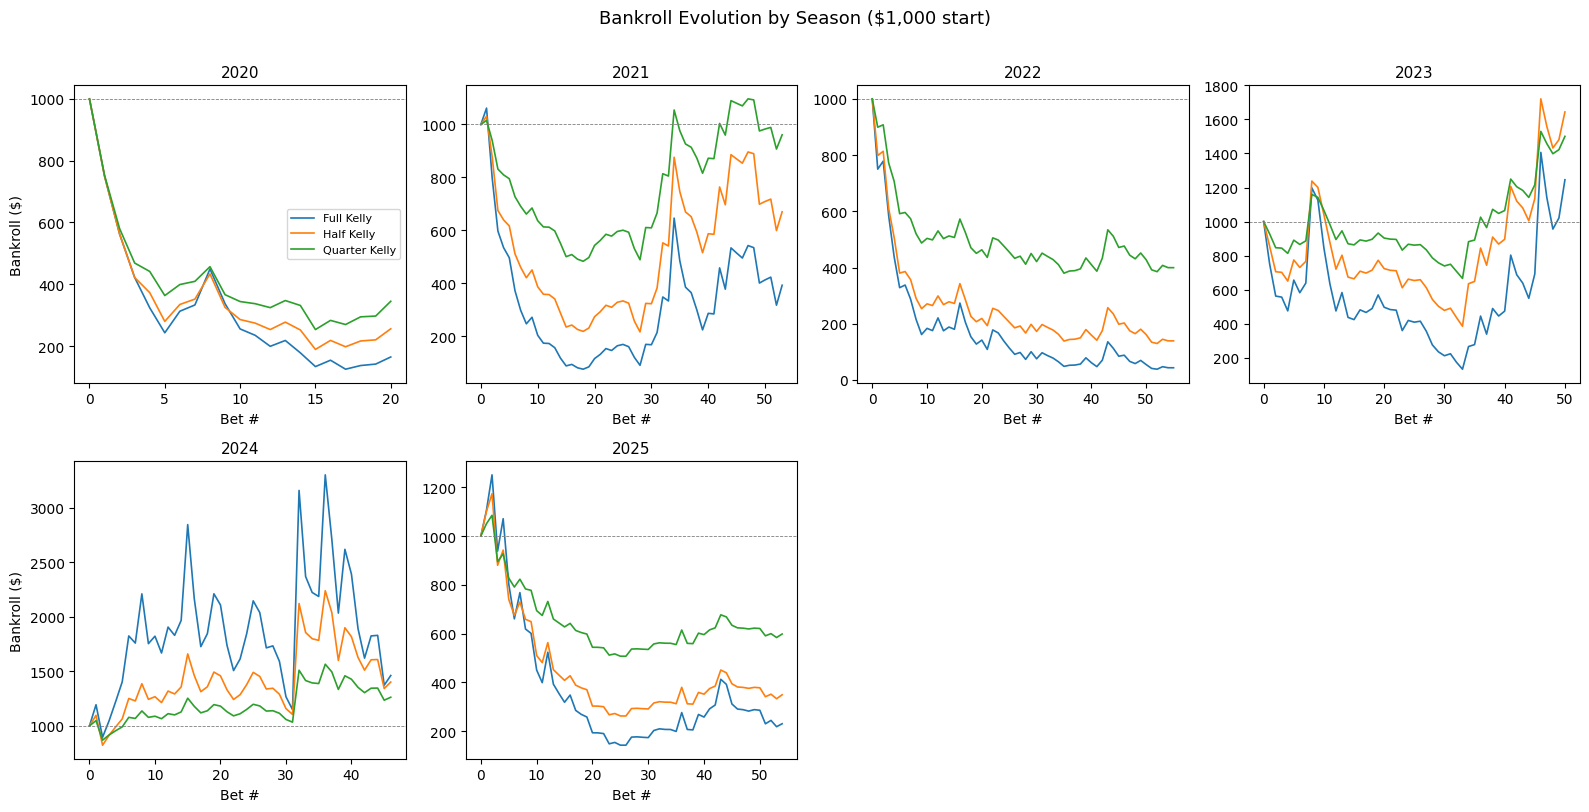

In [13]:
seasons_with_bets = [s for s in sorted(season_results.keys()) if season_results[s]]

if not seasons_with_bets:
    print("No seasons with bets to plot.")
else:
    ncols = min(4, len(seasons_with_bets))
    nrows = (len(seasons_with_bets) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharey=False)
    if nrows * ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for idx, test_season in enumerate(seasons_with_bets):
        bets = season_results[test_season]
        ax = axes[idx]
        for label, scale in kelly_scales.items():
            result = simulate_kelly(bets, bankroll=STARTING_BANKROLL, kelly_scale=scale)
            ax.plot(result["bankroll_curve"], label=label, linewidth=1.2)

        ax.axhline(STARTING_BANKROLL, color="grey", linestyle="--", linewidth=0.6)
        ax.set_title(f"{test_season}", fontsize=11)
        ax.set_xlabel("Bet #")
        if idx % ncols == 0:
            ax.set_ylabel("Bankroll ($)")

    for idx in range(len(seasons_with_bets), len(axes)):
        axes[idx].set_visible(False)

    axes[0].legend(fontsize=8)
    fig.suptitle(
        f"Bankroll Evolution by Season (${STARTING_BANKROLL:,.0f} start)",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()

## Aggregate Multi-Season Simulation

Roll the bankroll forward across all test seasons (2019-2025) to see cumulative P&L.

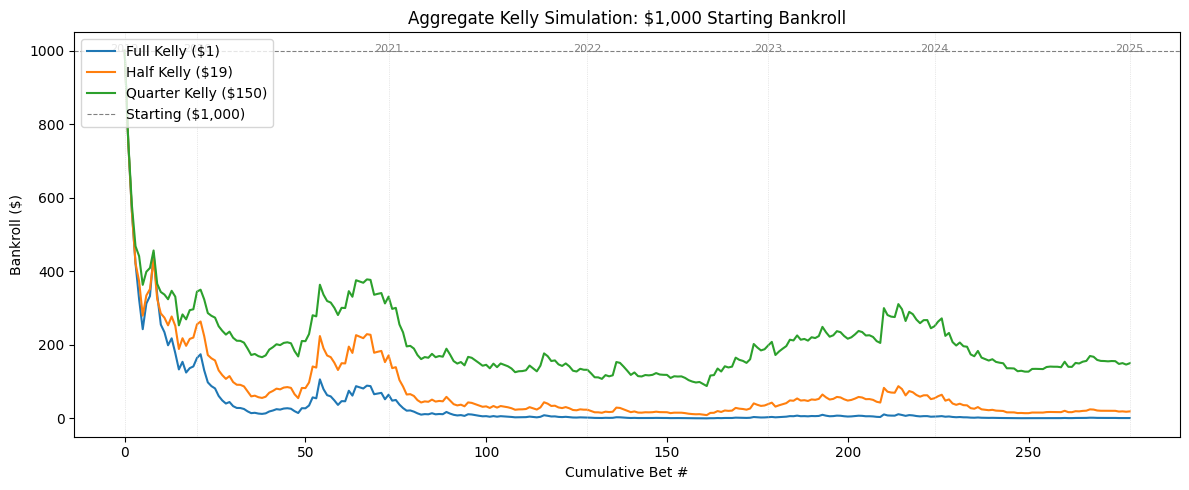


Aggregate Results ($1,000 starting bankroll)
  Full Kelly     : $     1.18  (P&L   -998.82, 278 bets, 39% wins, ROI -46.5%)
  Half Kelly     : $    19.23  (P&L   -980.77, 278 bets, 39% wins, ROI -35.2%)
  Quarter Kelly  : $   150.15  (P&L   -849.85, 278 bets, 39% wins, ROI -24.5%)


In [14]:
# Aggregate: chain all bets across seasons with rolling bankroll
all_bets = []
for test_season in sorted(season_results.keys()):
    all_bets.extend(season_results[test_season])

if not all_bets:
    print("No bets to simulate.")
else:
    fig, ax = plt.subplots(figsize=(12, 5))

    aggregate_results = {}
    for label, scale in kelly_scales.items():
        result = simulate_kelly(all_bets, bankroll=STARTING_BANKROLL, kelly_scale=scale)
        aggregate_results[label] = result
        ax.plot(
            result["bankroll_curve"],
            label=f"{label} (${result['final_bankroll']:,.0f})",
            linewidth=1.5,
        )

    ax.axhline(
        STARTING_BANKROLL, color="grey", linestyle="--", linewidth=0.8,
        label=f"Starting (${STARTING_BANKROLL:,.0f})",
    )

    # Season boundary markers
    bet_idx = 0
    for test_season in sorted(season_results.keys()):
        bet_idx += len(season_results[test_season])
        ax.axvline(bet_idx, color="lightgrey", linestyle=":", linewidth=0.5)
        ax.text(
            bet_idx, ax.get_ylim()[1] * 0.95, str(test_season),
            fontsize=8, ha="center", color="grey",
        )

    ax.set_xlabel("Cumulative Bet #")
    ax.set_ylabel("Bankroll ($)")
    ax.set_title(f"Aggregate Kelly Simulation: ${STARTING_BANKROLL:,.0f} Starting Bankroll")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    # Summary table
    print(f"\nAggregate Results (${STARTING_BANKROLL:,.0f} starting bankroll)")
    print("=" * 70)
    for label, result in aggregate_results.items():
        profit = result["final_bankroll"] - STARTING_BANKROLL
        print(
            f"  {label:15s}: ${result['final_bankroll']:>9,.2f}  "
            f"(P&L {profit:>+9,.2f}, {result['bets_placed']} bets, "
            f"{result['win_rate']:.0%} wins, ROI {result['roi']:+.1%})"
        )

## Takeaways

- **Kelly criterion sizes bets optimally** — larger stakes when the model has a strong edge, no bet when there's no edge.
- **Half Kelly is recommended** — captures ~75% of full Kelly's expected growth while cutting variance roughly in half.
- **Quarter Kelly is the conservative option** — smoother bankroll curve, better for risk-averse bettors.
- **Odds are from BetsAPI** — scraped via `scripts/fetch_odds.py` from betsapi.com league page, then odds fetched from the b365api.com REST API.
- **To refresh odds**: `poetry run python scripts/fetch_odds.py`